In [144]:
import os

import polars as pl
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, HTML
from collections.abc import Iterator
from statsmodels.tsa.seasonal import STL, DecomposeResult

from src.etl import ETL

In [145]:
BASE_PATH: str = os.path.join('.', 'src', 'files')
RANDOM_SEED: float = 0

sns.set_theme(style="darkgrid", palette="dark")

In [146]:
df_raw: pl.DataFrame = pl.read_csv(
    os.path.join(BASE_PATH, 'mock_data', 'mock_sales_data.csv'),
    schema_overrides = {
        'SaleDate': pl.Date,
        'ProductID': pl.String,
        'ASP': pl.Float32,
        'QT': pl.Int32,
    }
)

In [147]:
df_raw.head(5)

SaleDate,ProductID,ASP,QT
date,str,f32,i32
2020-01-01,"""P001""",97.769997,13
2020-01-01,"""P001""",97.260002,16
2020-01-01,"""P001""",97.110001,12
2020-01-01,"""P001""",96.580002,21
2020-01-01,"""P001""",97.230003,12


In [148]:
df_raw.select(pl.col('ProductID')).unique().count().item()

10

In [149]:
df_raw = df_raw.with_columns(
    pl.col('SaleDate').dt.year().alias('Y'),
    pl.col('SaleDate').dt.month().alias('M'),
    pl.concat_str(
        pl.col('SaleDate').dt.to_string('%Y'),
        pl.col('SaleDate').dt.to_string('%m'),
        separator = '/'
    ).alias('YearMonth')
)

In [150]:
for product in df_raw.sort(by='ProductID')['ProductID'].unique().to_numpy():
    min_date: dt.date = df_raw.filter(pl.col('ProductID') == product)['SaleDate'].min()
    max_date: dt.date = df_raw.filter(pl.col('ProductID') == product)['SaleDate'].max()

    print(f'Product: {product} - Min Date: {min_date} - Max Date: {max_date}')

Product: P008 - Min Date: 2020-01-01 - Max Date: 2026-06-17
Product: P007 - Min Date: 2020-01-01 - Max Date: 2026-06-17
Product: P010 - Min Date: 2020-01-01 - Max Date: 2026-06-17
Product: P004 - Min Date: 2020-01-01 - Max Date: 2026-06-17
Product: P003 - Min Date: 2020-01-01 - Max Date: 2026-06-17
Product: P006 - Min Date: 2020-01-01 - Max Date: 2026-06-17
Product: P005 - Min Date: 2020-01-01 - Max Date: 2026-06-17
Product: P009 - Min Date: 2020-01-01 - Max Date: 2026-06-17
Product: P002 - Min Date: 2020-01-01 - Max Date: 2026-06-17
Product: P001 - Min Date: 2020-01-01 - Max Date: 2026-06-17


In [151]:
df_raw = df_raw.filter(
    pl.col('SaleDate') < dt.date(2026, 6, 1)
)

In [152]:
etl: ETL = ETL()

In [153]:
df_QT_noiseless: pd.DataFrame = etl.prepare_dataframe(
    df = df_raw.to_pandas(),
    x = 'ProductID',
    y = 'QT'
)

df_QT_noiseless: pl.DataFrame = pl.from_pandas(df_QT_noiseless)

In [154]:
df_QT_noiseless

ProductID,ds,y
str,datetime[μs],i32
"""P001""",2020-01-01 00:00:00,2952
"""P005""",2020-01-01 00:00:00,1982
"""P003""",2020-01-01 00:00:00,1722
"""P006""",2020-01-01 00:00:00,655
"""P010""",2020-01-01 00:00:00,2668
…,…,…
"""P003""",2026-05-01 00:00:00,3731
"""P002""",2026-05-01 00:00:00,3760
"""P001""",2026-05-01 00:00:00,3338


In [155]:
def line_plot(df: pl.DataFrame, x: str, y: str, hue: str) -> None:
    fig_in, ax_in = plt.subplots(figsize=(18, 6))
    sns.lineplot(data=df, x=x, y=y, hue=hue, ax=ax_in)

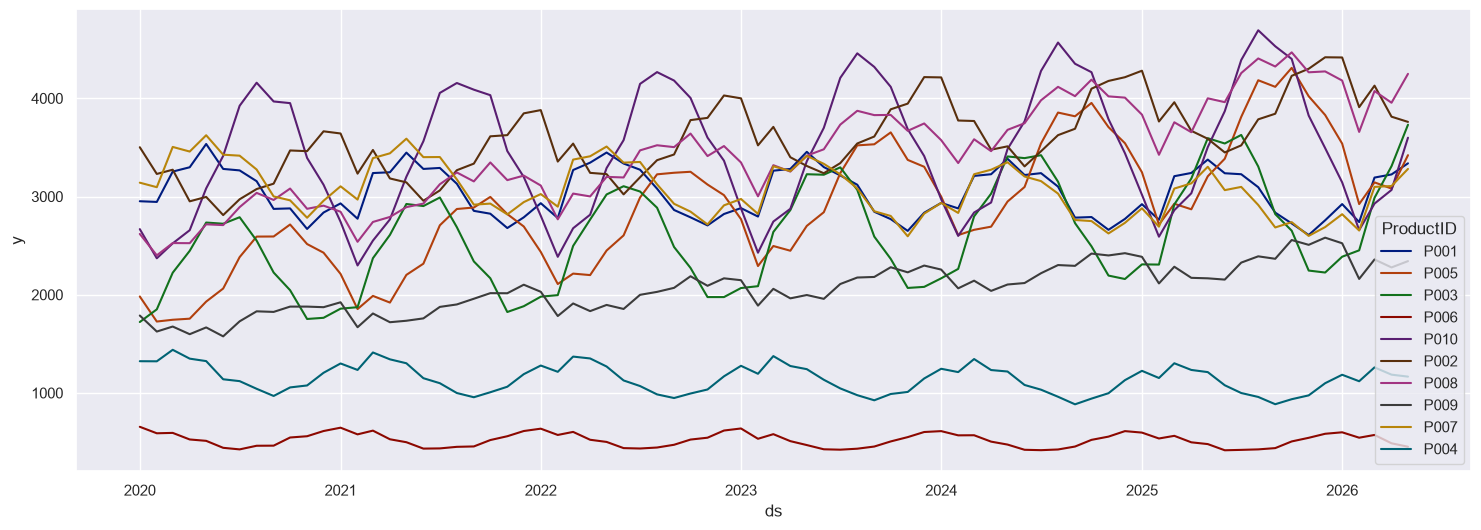

In [156]:
line_plot(df_QT_noiseless, x='ds', y='y', hue='ProductID')

In [157]:
noise: np.ndarray = np.ones(len(df_QT_noiseless))
products: list[str] = df_QT_noiseless['ProductID'].unique().sort().to_list()

for i, product in enumerate(products):
    mask: np.ndarray[bool] = (df_QT_noiseless["ProductID"] == product).to_numpy()
    mask_size: int = mask.sum()
    noise[mask]: Iterator[float] = np.random.default_rng(RANDOM_SEED + i).normal(1.0, 0.05, mask_size)

df_QT: pl.DataFrame = df_QT_noiseless.with_columns(
    (pl.col("y") * pl.Series("noise", noise)).round(2).alias("y")
)

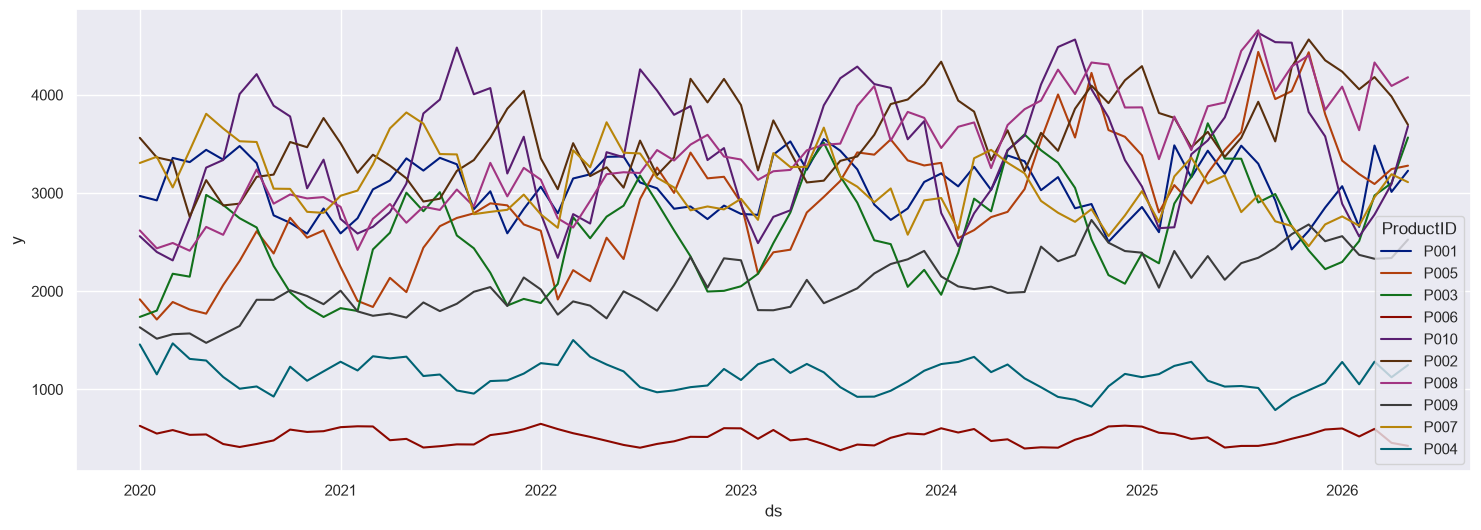

In [158]:
line_plot(df_QT, x='ds', y='y', hue='ProductID')

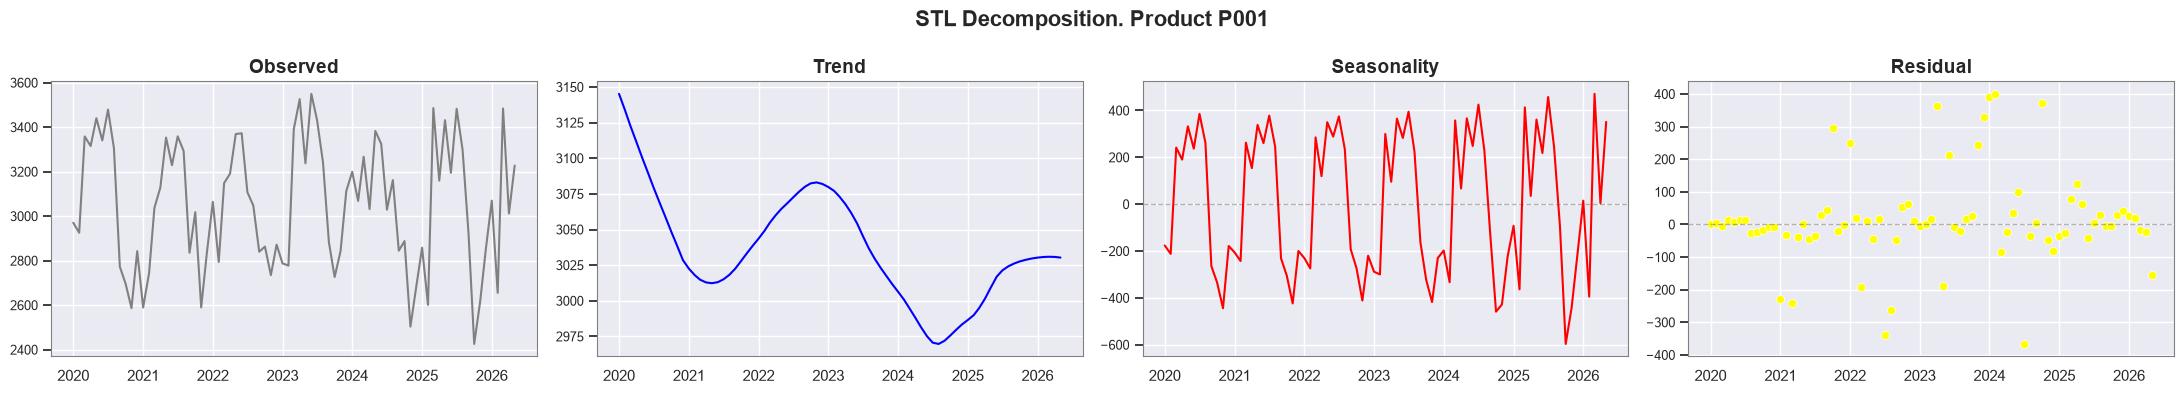

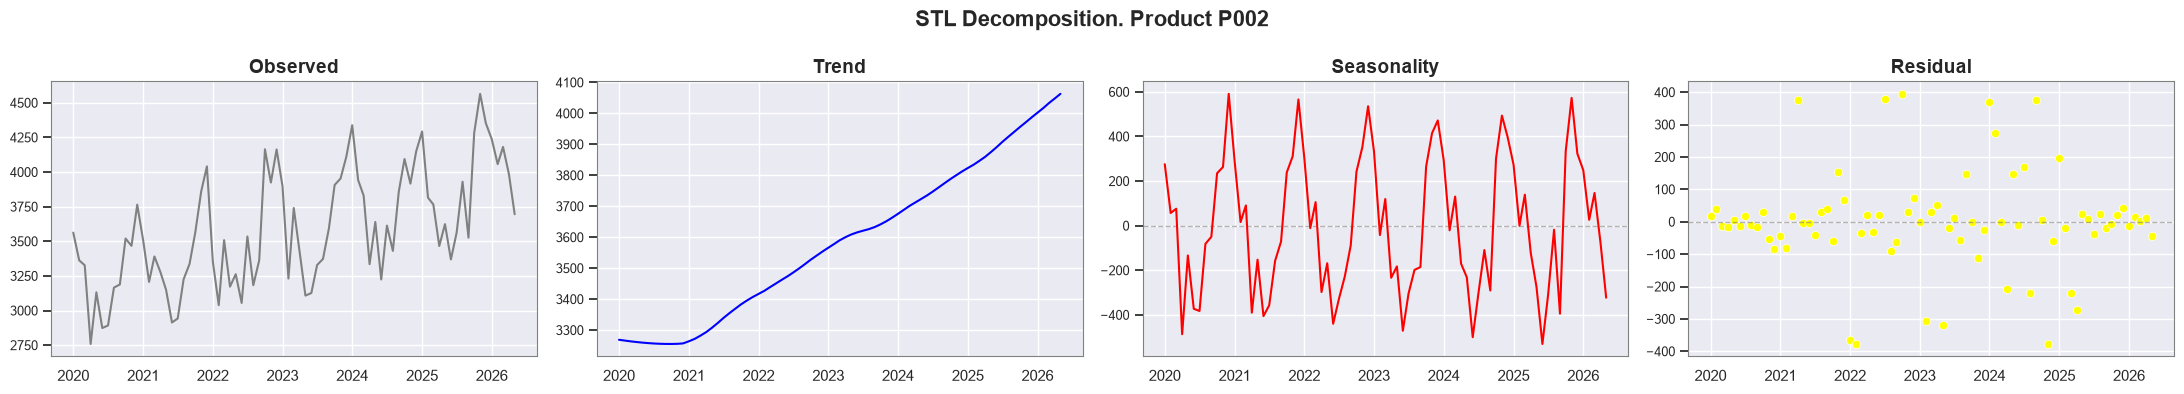

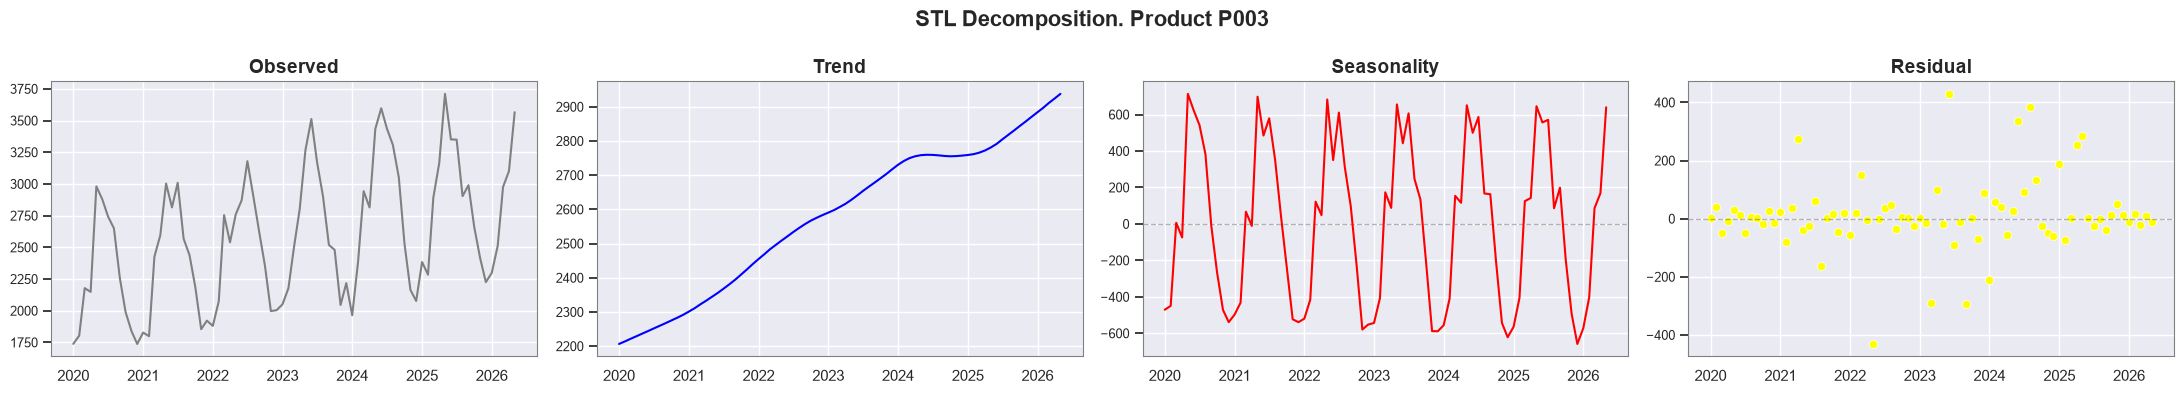

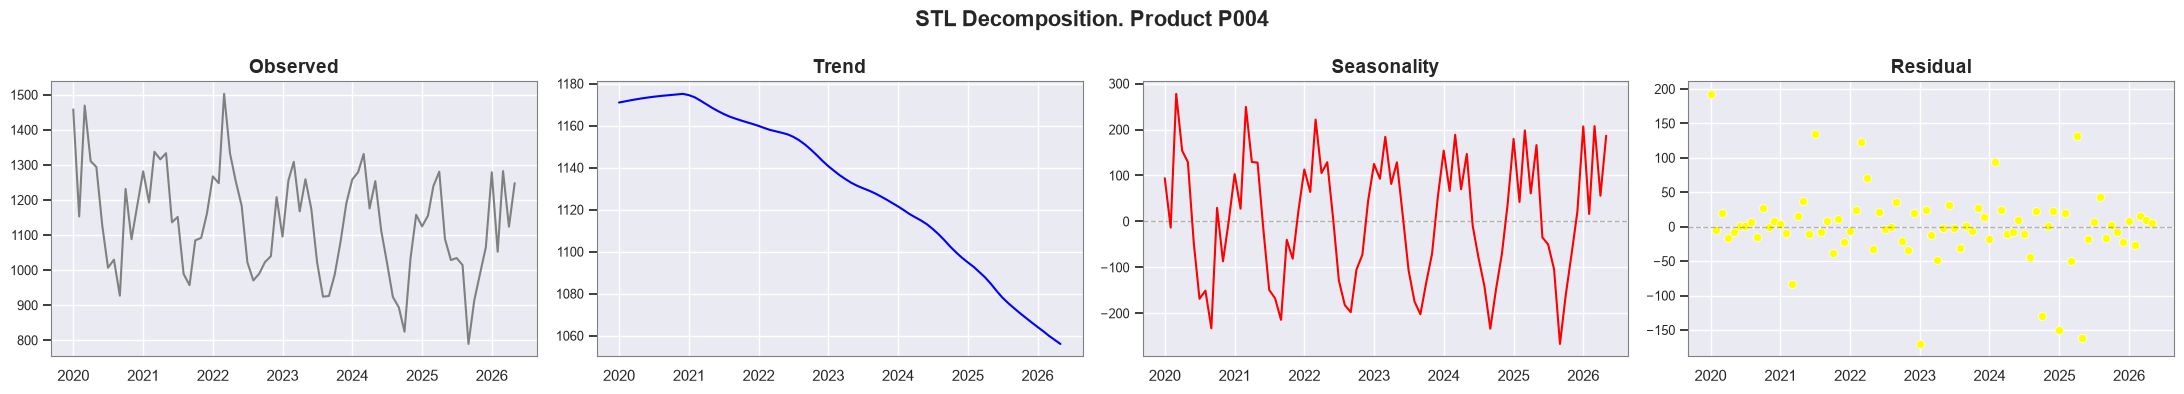

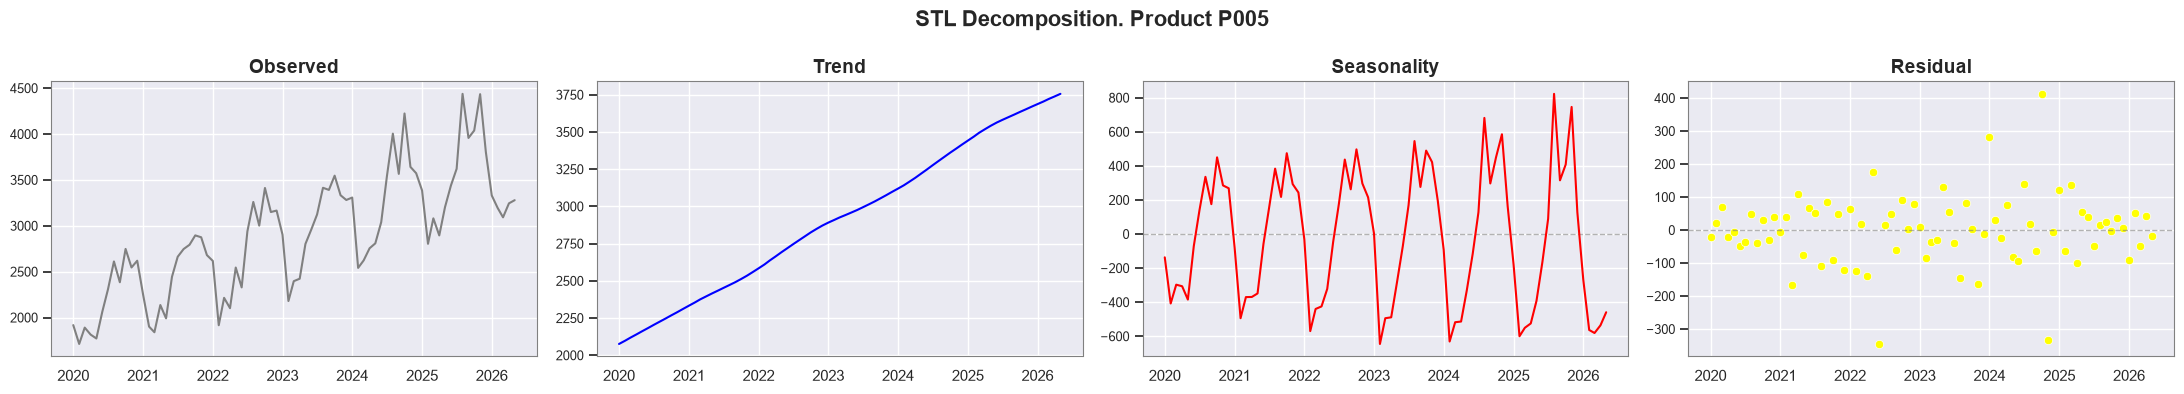

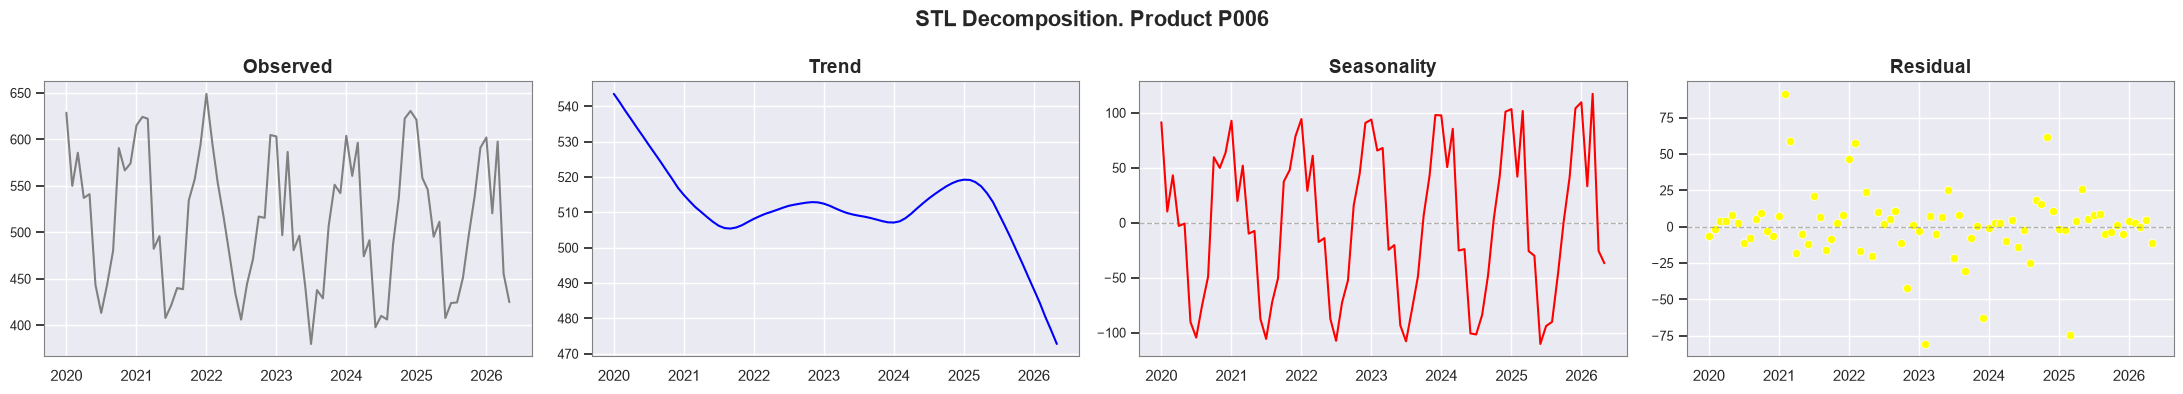

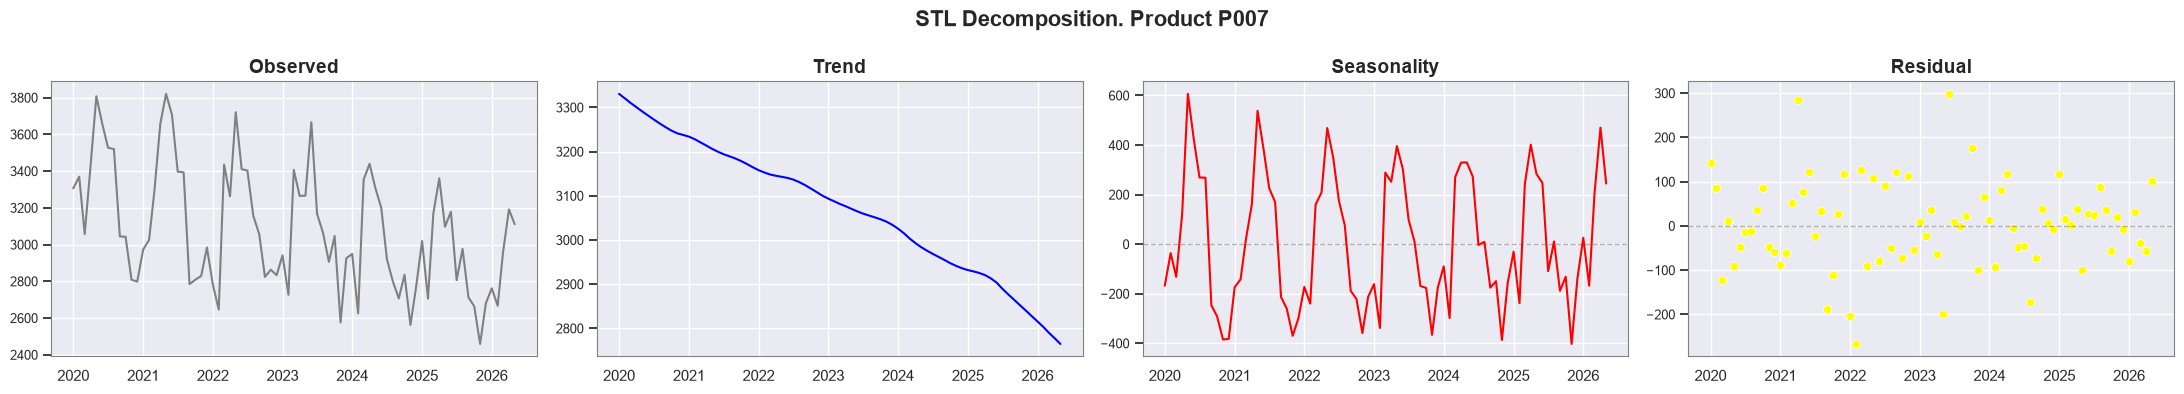

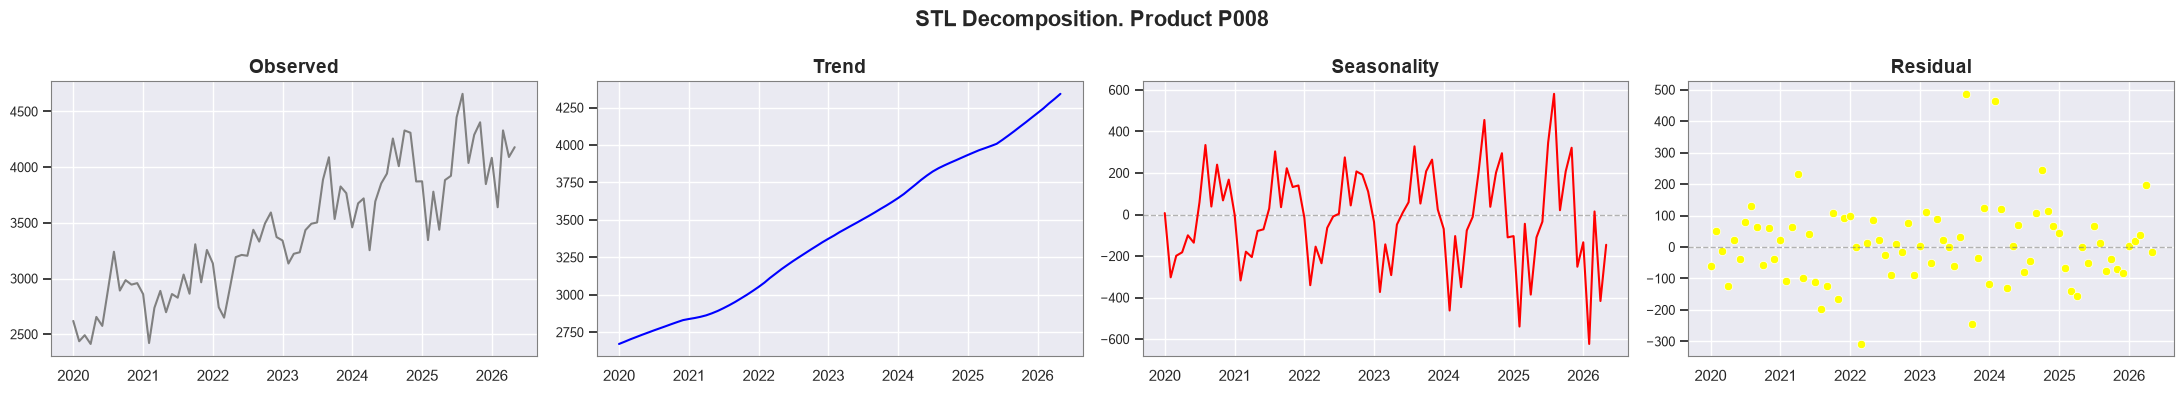

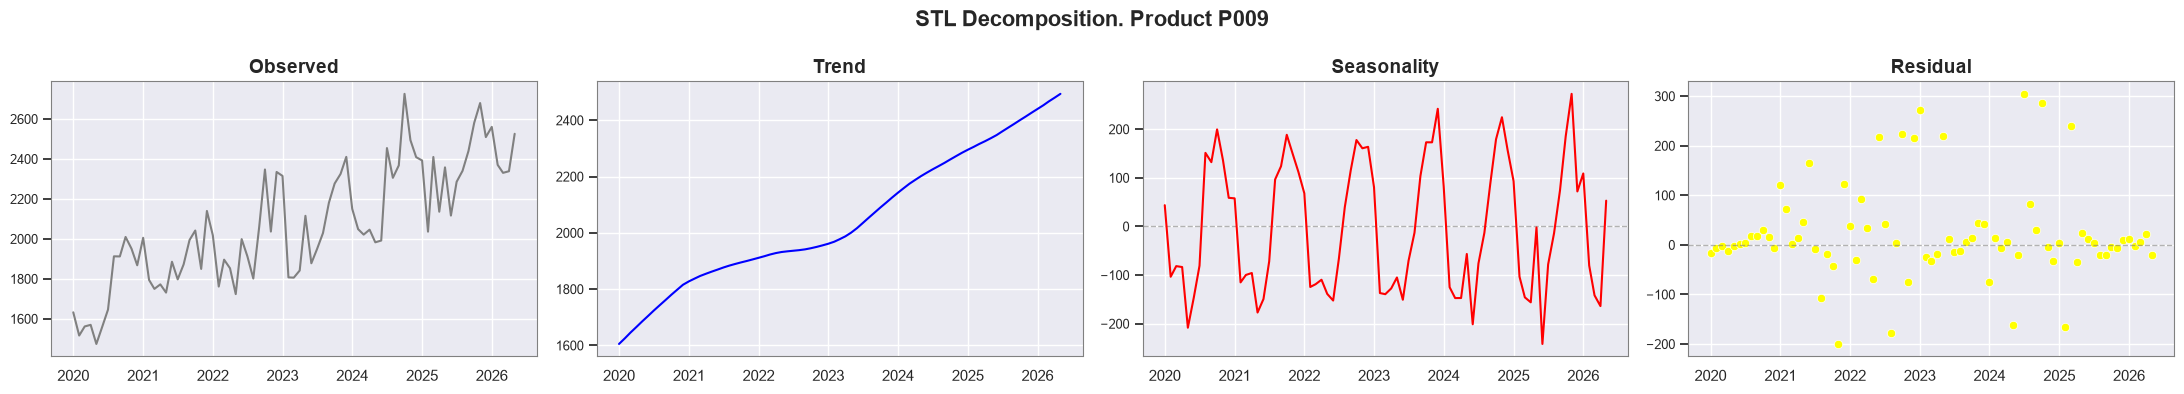

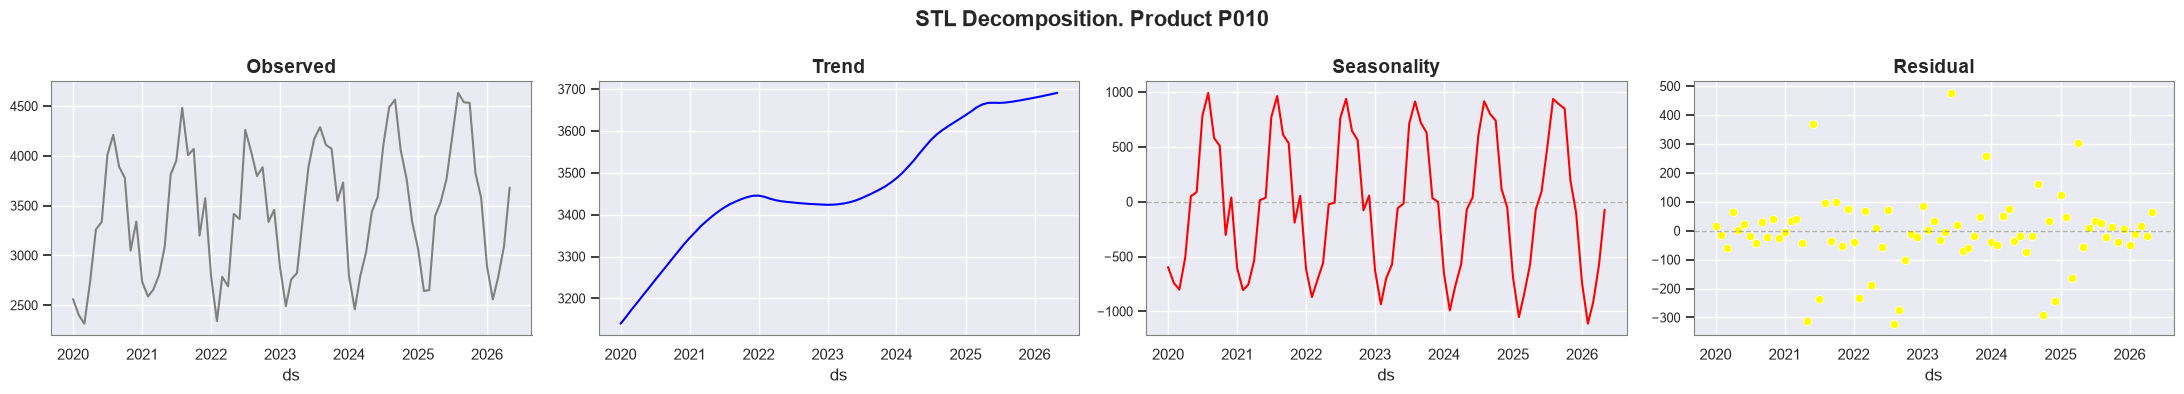

In [159]:
df_QT_pandas: pd.DataFrame = df_QT.to_pandas()
df_QT_pandas['ds'] = pd.to_datetime(df_QT_pandas['ds'])

products: list[str] = sorted(df_QT_pandas['ProductID'].unique().to_numpy())
product_signal_decomposition: dict[str, DecomposeResult] = {}

components_colors: dict[str, str] = {
    "Observed":   "grey",
    "Trend":      "blue",
    "Seasonality":"red",
    "Residual":   "yellow",
}

for row_idx, product in enumerate(products):
    fig, axes = plt.subplots(
        figsize = (22, 4),
        nrows = 1,
        ncols = 4,
    )

    fig.suptitle(f"STL Decomposition. Product {product}", fontsize=16, fontweight="bold")

    product_series: pd.Series = (
        df_QT_pandas[df_QT_pandas["ProductID"] == product]
        .set_index("ds")["y"]
        .asfreq("MS")
    )
    stl: STL = STL(product_series, period=12, robust=True)
    result: DecomposeResult = stl.fit()

    components: dict[str, pd.Series] = {
        'Observed': product_series,
        'Trend': result.trend,
        'Seasonality': result.seasonal,
        'Residual': result.resid
    }

    for col_idx, (component_name, component_series) in enumerate(components.items()):
        axes[col_idx].set_title(
            component_name,
            fontsize=14,
            fontweight='bold',
        )
        ax = axes[col_idx]

        if component_name in ('Seasonality', 'Residual'):
            ax.axhline(0, color='grey', linewidth=1, linestyle='--', alpha=0.6)

        if component_name == 'Residual':
            sns.scatterplot(
                x=component_series.index,
                y=component_series.values,
                ax=ax,
                color=components_colors[component_name],
            )
        else:
            sns.lineplot(
                x=component_series.index,
                y=component_series.values,
                ax=ax,
                color=components_colors[component_name],
            )

        if row_idx < len(products) - 1:
            ax.set_xlabel(None)

        ax.tick_params(axis="y", labelsize=9, left=True, labelleft=True)

        for spine in ax.spines.values():
                spine.set_linewidth(0.8)
                spine.set_color("grey")

    plt.tight_layout()
    plt.show()
    display(HTML("<div style='margin-bottom: 40px'></div>"))